<a href="https://colab.research.google.com/github/juliafarah/MVP_Data_Analysis/blob/main/MVP_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP Data Analysis**

**Aluna:** Julia Farah *(Matr.: )*

**Data:** 12/04/2026

**Dataset**: Logística Global e Gestão de Riscos (Setor de Óleo e Gás)

### **Introdução**

* **Definição e Descrição do Problema**

Embora o setor de origem do dataset não tenha sido especificado na descrição original do Kaggle, para fins de direcionamento desta análise de negócio, este MVP considerará os dados como pertencentes à EDA Offshore, uma empresa fictícia do setor de Óleo e Gás.

Em operações de exploração de petróleo e gás em águas profundas, a logística é um fator crítico da empresa. Para a EDA Offshore, a entrega pontual de equipamentos e suprimentos para uma unidade FPSO (Floating Production Storage and Offloading) depende de uma rede global complexa. Atrasos ou interrupções nesse fluxo podem comprometer a continuidade da produção e a segurança operacional.


**Fonte:** [Kaggle](https://www.kaggle.com/datasets/nudratabbas/global-supply-chain-risk-and-logistics-2024-2026)


* **Objetivo do MVP**

Este projeto utiliza um dataset de movimentações de carga globais para identificar os principais fatores de risco, atraso e interrupção na cadeia de suprimentos. O foco é realizar uma Análise Exploratória de Dados (EDA) que suporte na tomada de decisão estratégica d gerência, visando mitigar atrasos e perdas de carga com base em indicadores de instabilidade geopolítica e eventos climáticos extremos.

* **Tipo de Aprendizado:** Supervisionado.

* **Definição dos Atributos**

**`Shipment_ID`** : Identificador único da carga.

**`Date`** : Data de despacho da carga (2024 a 2026).

**`Origin_Port`** : Portos de origem (Hubs globais)

**`Destination_Port`** : Portos de destino (Hubs globais).

**`Transport_Mode`** : Modal (Sea, Air, Rail, Road).

**`Distance_km`** : Distância total percorrida.

**`Weight_MT`** : Peso da carga em Toneladas Métricas.

 **`Fuel_Price_Index`** : Índice de custo de combustível no despacho.

 **`Geopolitical_Risk_Score`** : Índice de risco regional (0 a 10).

 **`Weather_Condition`** : Condição climática (Clear, Storm, Hurricane, etc).

 **`Carrier_Reliability_Score`** : Score de confiabilidade do transportador (0.5 a 1.0).

**`Lead_Time_Days`** : Tempo real de entrega (Variável Alvo para Regressão).

**`Disruption_Occurred`** : Flag de interrupção ou atraso (0: Não / 1: Sim).

* **Perguntas para a Análise Exploratória (EDA)**


**1. Qual é a taxa geral de atraso (delayed) no dataset?**

**Objetivo:** Entender o "baseline" do problema. Se 50% dos pedidos atrasam, temos um problema sistêmico.

**2. Qual o método de envio (shipping_method) que apresenta a maior frequência de atrasos?**

Objetivo: Verificar se o transporte marítimo (Sea), comum na SBM, é mais arriscado que o aéreo (Air).

**3. Existe uma distância crítica (shipping_distance_km) a partir da qual o atraso se torna quase certo?**

Objetivo: Identificar se o problema está em rotas internacionais de longa distância.

**4. Pedidos de prioridade "Critical" estão sendo entregues com menos atraso do que pedidos "Low"?**

Objetivo: Avaliar se a operação realmente consegue priorizar o que é urgente para a plataforma.

**5. O tempo de processamento interno (processing_time_hours) é maior em pedidos que acabam atrasando?**

Objetivo: Descobrir se o gargalo é "dentro de casa" (armazém/alfândega) ou "na rua" (transporte).

**6. Como as condições climáticas (weather_condition) afetam a probabilidade de atraso em cada modal?**

Objetivo: Entender se tempestades (Storm) inviabilizam o transporte ou se a operação é resiliente.

**7. Existe correlação entre o Score de Confiabilidade do Fornecedor (supplier_reliability_score) e a ocorrência de atrasos?**

Objetivo: Validar se fornecedores com nota baixa são realmente os responsáveis pelos maiores riscos.

# **1. Pre Processamento dos Dados**

In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Carregando o arquivo (certifique-se de que o nome está idêntico ao do arquivo subido)
df = pd.read_csv('https://raw.githubusercontent.com/juliafarah/MVP_Data_Analysis/refs/heads/main/global_supply_chain_risk_2026.csv')

# Visualizando as 5 primeiras linhas para confirmar que funcionou
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


* **Detalhes do dataset:**

In [3]:
print("Quantidade de linhas e colunas:", df.shape)

Quantidade de linhas e colunas: (5000, 14)


* **Tipo de cada coluna:**

In [4]:
# Mostra o tipo de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

* **Verificação de valores nulos:**

In [5]:
df.isnull().sum()

,0
Shipment_ID,0
Date,0
Origin_Port,0
Destination_Port,0
Transport_Mode,0
Product_Category,0
Distance_km,0
Weight_MT,0
Fuel_Price_Index,0
Geopolitical_Risk_Score,0


* **Resumo estatístico:**

In [6]:
df.describe()


,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


* **Convertendo o tipo da coluna `order_date` para datetime**

In [7]:

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   object        
 1   Date                       5000 non-null   datetime64[ns]
 2   Origin_Port                5000 non-null   object        
 3   Destination_Port           5000 non-null   object        
 4   Transport_Mode             5000 non-null   object        
 5   Product_Category           5000 non-null   object        
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   object        
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_T

*   **Definindo colunas por tipo (numericas e categoricas)**


In [8]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Atributos Numéricos: {colunas_numericas}\n")
print(f"Atributos Categóricos: {colunas_categoricas}")

Atributos Numéricos: ['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']

Atributos Categóricos: ['Shipment_ID', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']


* **Verificação manual de inconsistências comuns em Supply Chain:**


In [9]:
inconsistencias = df[(df['Lead_Time_Days'] <= 0) | (df['Distance_km'] <= 0)].shape[0]
print(f"\nInconsistências detectadas (LT<0): {inconsistencias}")


Inconsistências detectadas (LT<0): 0


* **Tipo de distribuição de cada atributo numéricos:**

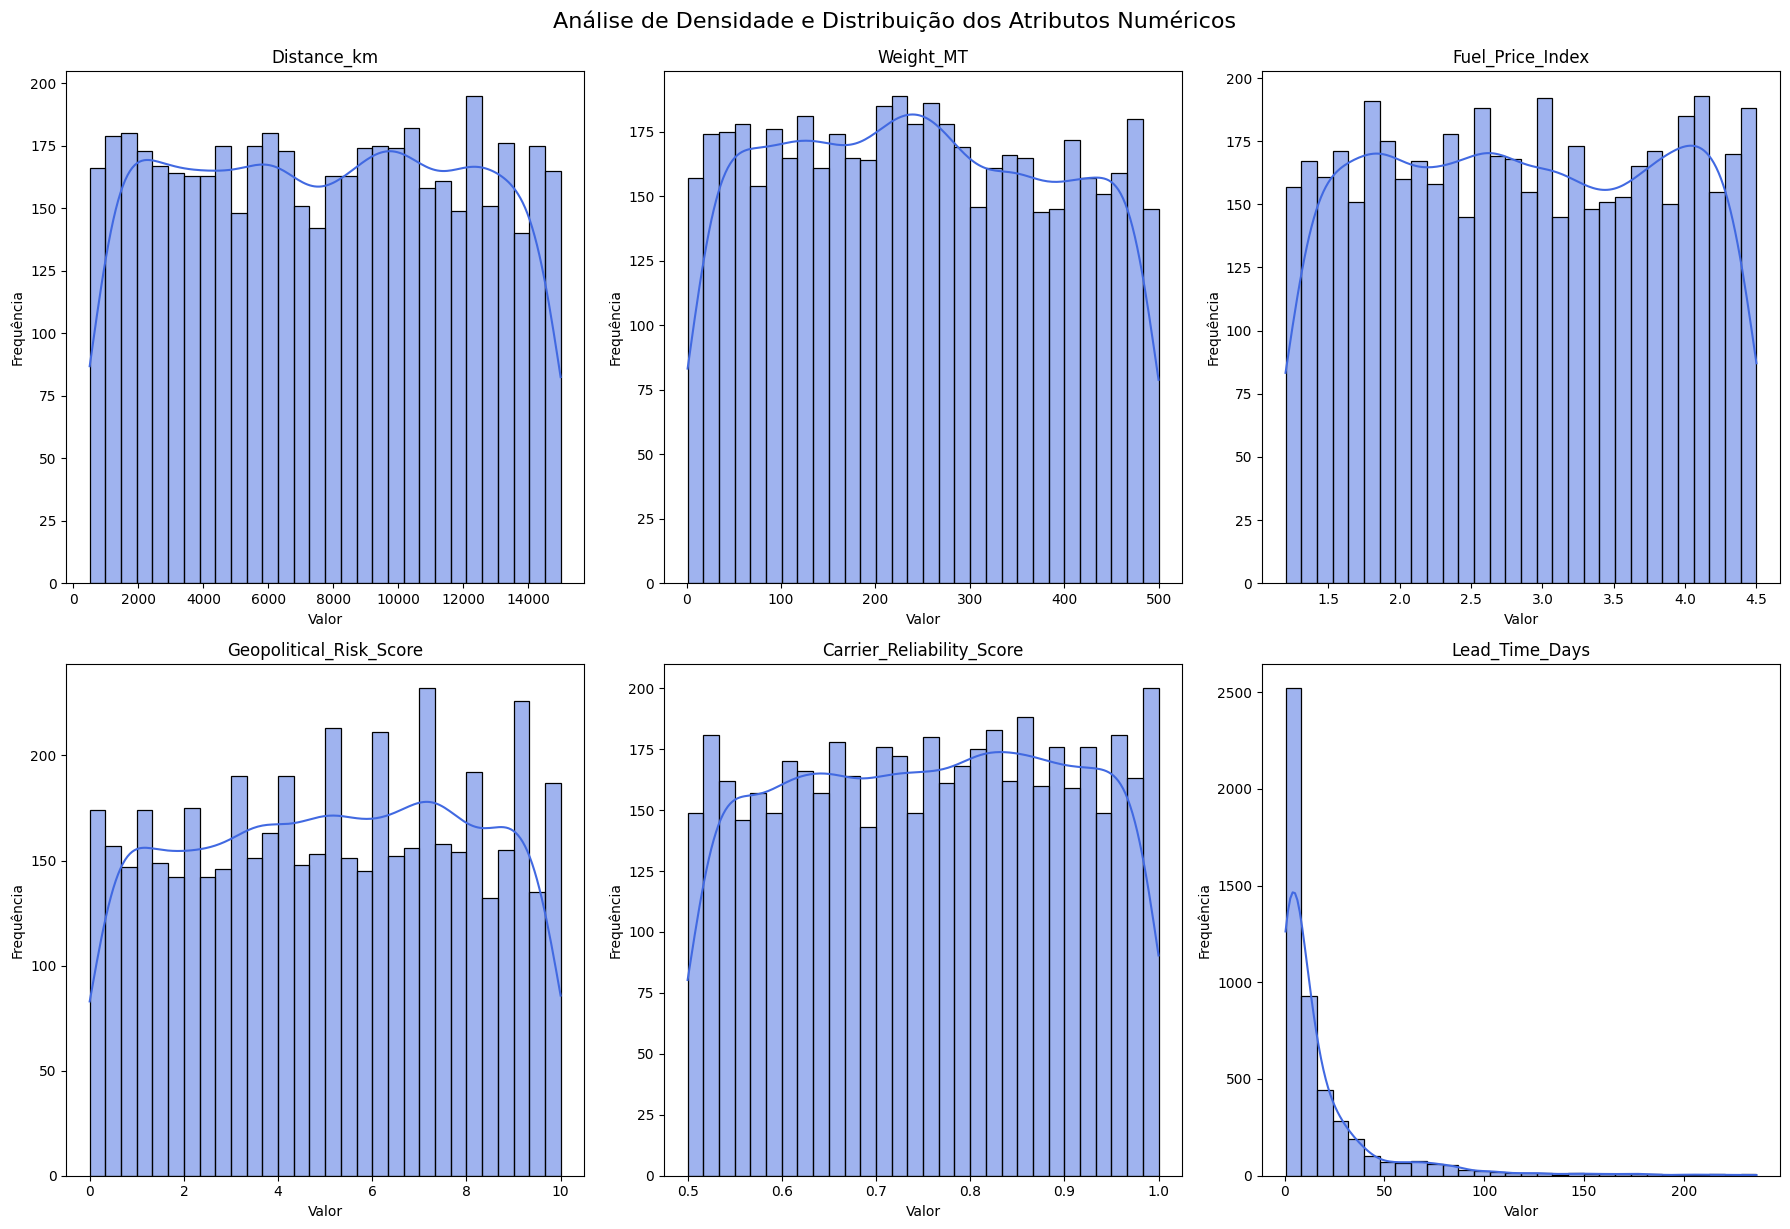

In [10]:
plt.figure(figsize=(18, 12))


cols_to_plot = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index',
                'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days']

for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='royalblue', bins=30)
    plt.title(col)
    plt.xlabel('Valor')
    plt.ylabel('Frequência')

plt.tight_layout()
plt.suptitle('Análise de Densidade e Distribuição dos Atributos Numéricos', fontsize=16, y=1.02)
plt.show()

Insights interessantes: A visualização das distribuições mostra que a maioria dos atributos (como Risco Geopolítico e Distância) segue uma Distribuição Uniforme, garantindo que o modelo seja treinado em uma gama variada de situações sem sobreposição de classes. Entretanto, o `Lead_Time_Days` exibe uma Distribuição Exponencial/Log-normal, concentrada em valores baixos, mas com uma cauda longa.

* **Matriz de Correlação:**


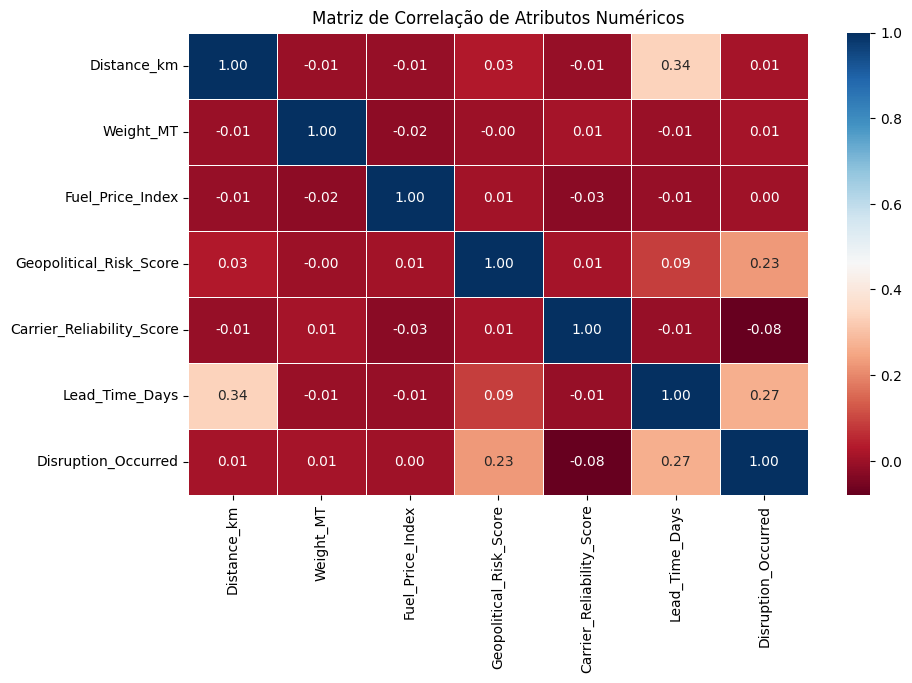

In [11]:

plt.figure(figsize=(10, 6))

# Removendo ID e datas para a correlação numérica
corr = df[colunas_numericas].corr()
sns.heatmap(corr, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação de Atributos Numéricos')
plt.show()

**Insights interessantes:**

Destaca-se a correlação positiva de **0.34** entre **`Distance_km`** e **`Lead_Time_Days`**, confirmando que a distância é um fator que mais impacta diretamente o tempo de entrega.

Outro ponto relevante é a correlação de **0.23** entre **`Geopolitical_Risk_Score`** e **`Disruption_Occurred`**, sugere que existe uma relação positiva, embora moderada, entre o risco geopolítico e a ocorrência de interrupções. Isso significa que, à medida que o risco geopolítico aumenta, a probabilidade de uma interrupção ocorrer na cadeia de suprimentos também tende a aumentar.

A ausência de correlações extremamente altas (acima de 0.8) entre variáveis independentes afasta o risco de multicolinearidade, garantindo estabilidade para futuros modelos de regressão ou classificação.

* **Verificando outliers (anomalias):**

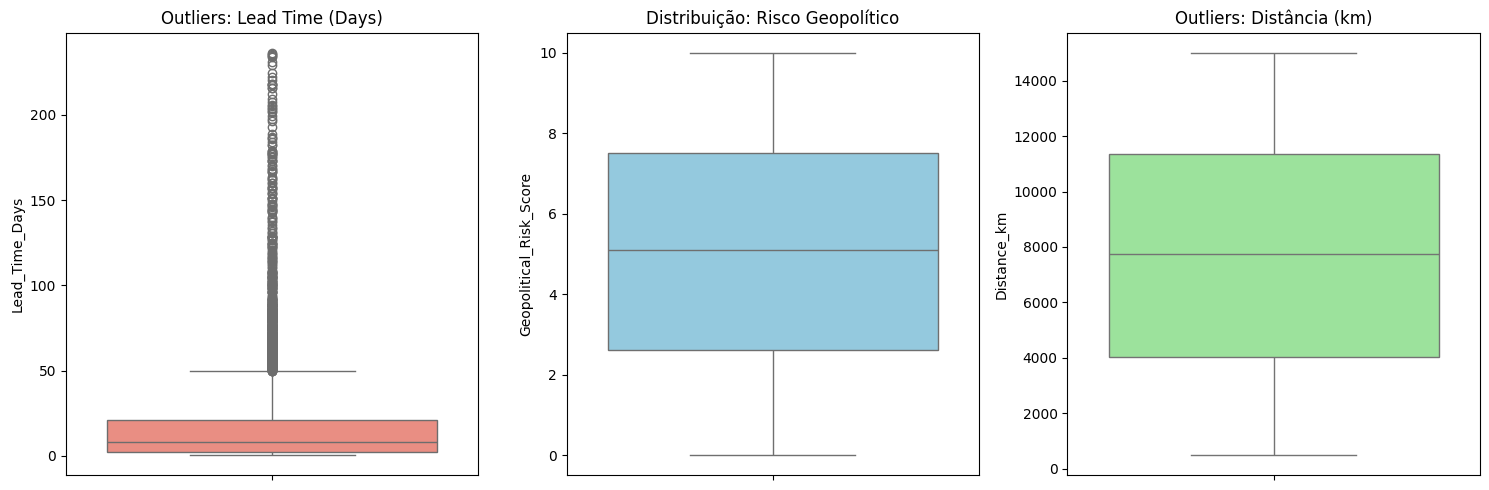

In [12]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Lead_Time_Days'], color='salmon')
plt.title('Outliers: Lead Time (Days)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Geopolitical_Risk_Score'], color='skyblue')
plt.title('Distribuição: Risco Geopolítico')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Distance_km'], color='lightgreen')
plt.title('Outliers: Distância (km)')

plt.tight_layout()
plt.show()

**Insights interessantes:** O boxplot de `Lead_Time_Days` apresenta uma forte assimetria positiva, com a mediana concentrada em valores baixos (entregas rápidas). No entanto, observa-se uma presença massiva de outliers superiores (eventos que ultrapassam 50 dias e chegam a 250 dias). Para empresas do setor de Óleo e Gás, esses pontos representam falhas críticas na cadeia de suprimentos que devem ser priorizadas, pois são casos onde o tempo de entrega saiu totalmente do controle operacional padrão.

* **Criando uma nova coluna para rankear a severidade de cada condição climática (`weather_condition`)**

In [13]:
# quais tipos de condicoes climaticas tem na coluna Weather_Condition
print("\nLista de valores únicos:")
print(df['Weather_Condition'].unique())


Lista de valores únicos:
['Hurricane' 'Storm' 'Rain' 'Fog' 'Clear']


In [14]:
# mantem a coluna original 'Weather_Condition' e cria a nova 'Weather_Severity_Rank'

mapping_clima = {
    'Clear': 1,
    'Rain': 2,
    'Fog': 3,
    'Storm': 3,
    'Hurricane': 4
}

# nova coluna de ranking
df['Weather_Severity_Rank'] = df['Weather_Condition'].map(mapping_clima)

# double check se a criaçao foi bem sucedida
print("Amostra dos dados com a nova coluna do ranking:")
display(df[['Weather_Condition', 'Weather_Severity_Rank']].head(10))

# media de Lead Time pelo ranking
print("\nLead Time médio por nível do ranking:")
display(df.groupby(['Weather_Condition', 'Weather_Severity_Rank'])['Lead_Time_Days'].mean())

print("\nO dataframe completo:")
df.head(10)

Amostra dos dados com a nova coluna do ranking:


,Weather_Condition,Weather_Severity_Rank
0,Hurricane,4
1,Storm,3
2,Rain,2
3,Hurricane,4
4,Fog,3
5,Rain,2
6,Storm,3
7,Fog,3
8,Clear,1
9,Storm,3



Lead Time médio por nível do ranking:


,,Lead_Time_Days
Weather_Condition,Weather_Severity_Rank,
Clear,1,6.698704
Fog,3,9.892847
Hurricane,4,53.501848
Rain,2,7.736049
Storm,3,19.299182



O dataframe completo:


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Weather_Severity_Rank
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,3
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,3
5,SC-10005,2024-08-16,Rotterdam,Marseille,Rail,Automotive,2761.92,44.98,4.06,2.2,Rain,0.869,2.16,1,2
6,SC-10006,2024-05-22,Shanghai,Antwerp,Rail,Pharmaceuticals,1342.21,388.62,1.31,2.6,Storm,0.981,2.99,0,3
7,SC-10007,2024-04-14,Busan,Antwerp,Air,Textiles,13059.55,423.93,3.32,5.7,Fog,0.558,1.25,1,3
8,SC-10008,2025-11-23,Dubai,Marseille,Air,Textiles,9216.17,91.73,3.72,5.0,Clear,0.855,0.62,1,1
9,SC-10009,2025-07-12,Los Angeles,Singapore,Rail,Electronics,10767.05,215.74,3.71,2.0,Storm,0.615,25.17,1,3


* **Concatenando os atributos Origin + Destiny em uma só para facilitar analises futuras.**

In [15]:
# Criando a coluna de Rota Combinada
df['Route'] = df['Origin_Port'] + ' ➔ ' + df['Destination_Port']

# Verificando as primeiras linhas
df.head(5)

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Weather_Severity_Rank,Route
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,4,Singapore ➔ Los Angeles
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,3,Singapore ➔ Shanghai
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2,Rotterdam ➔ Los Angeles
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,4,Busan ➔ Hamburg
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,3,Busan ➔ Singapore


# **2. Análise Exploratória dos Dados**

###**2.1: Qual a taxa de interrupção da companhia (2024 a 2026)?**

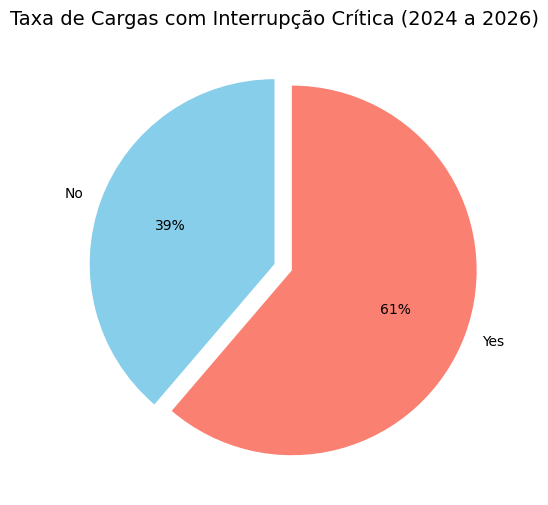

In [59]:
# 13. Taxa Global de Interrupções (Renomeado para Yes/No)
plt.figure(figsize=(6, 6))

# Agrupando e renomeando os índices para o gráfico
distribuicao_interrupcao = df.groupby('Disruption_Occurred').size()

distribuicao_interrupcao.index = distribuicao_interrupcao.index.map({0: 'No', 1: 'Yes'})

# Plotando o gráfico de pizza
distribuicao_interrupcao.plot.pie(
    autopct='%1.0f%%',
    colors=['skyblue', 'salmon'],
    startangle=90,
    explode=(0, 0.1)
)

plt.title('Taxa de Cargas com Interrupção Crítica (2024 a 2026)', fontsize=14)
plt.ylabel('') # Remove o nome da coluna lateral
plt.show()

**Insights relevantes:**

Os dados revelam um cenário de alta instabilidade operacional. O índice de interrupções críticas atinge **61%** do volume total de cargas monitoradas, enquanto apenas **39%** das entregas seguem o fluxo planejado (*Perfect Order*) sem intercorrências.

Uma **taxa de interrupção superior a 60%** é considerada crítica para operações. Este dado justifica a necessidade de um mergulho profundo nas variáveis de **Clima, Geopolítica e Modal**, a fim de identificar se estas falhas são sistêmicas ou concentradas em gargalos específicos.

###**2.2 Qual modal impacta mais a media do tempo de entrega?**

In [17]:
# fixando cores de cada modal para clareza na visualizacao dos dados/graficos
cores_modal = {
    'Sea': '#008080',   # azul
    'Rail': '#f94d00',  # laranja
    'Road': '#556b2f',  # verde
    'Air': '#ffdb58'    # amarelo
}

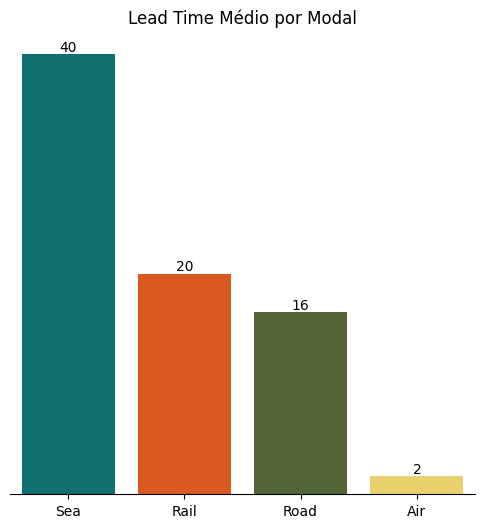

In [58]:
modal_mean = df.groupby('Transport_Mode')['Lead_Time_Days'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(6, 6))
sns.barplot(data=modal_mean, x='Transport_Mode', y='Lead_Time_Days', hue='Transport_Mode', palette=cores_modal, legend=False)
plt.title('Lead Time Médio por Modal')
plt.ylabel('Média de Lead Time (Dias)')
plt.xlabel('')
# Adicionar rótulos de dados (Lead Time médio em dias) em cada barra
for index, row in modal_mean.iterrows():
    plt.text(index, row['Lead_Time_Days'], f"{row['Lead_Time_Days']:.0f}", color='black', ha="center", va="bottom")

plt.yticks([])
plt.ylabel('')

ax = plt.gca()

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.show()

**Insights relevantes:**

* **Modal Sea (Marítimo)**: Por percorrer as maiores distâncias e lidar com grandes volumes, apresenta o maior Lead Time médio (**40 dias**). Na prática, uma carga marítima leva, em média, **1 mês e 10 dias** para chegar ao destino final, o que exige um planejamento de estoque muito mais antecipado.

* **Modais Terrestres (Rail e Road)**: Ambos operam com um tempo de entrega inferior a um mês (**20 e 16 dias, respectivamente**). Comparados ao modal marítimo, possuem um Lead Time **50% e 60%,  respectivamente,** inferior, oferecendo uma agilidade intermediária para a malha logística.

* **Modal Air (Aéreo)**: É o modal de resposta imediata, levando apenas **2 dias** para a entrega final. Sendo o mais rápido entre os quatro analisados, ele se consolida como a via preferencial para itens de altíssima urgência, embora com as restrições de carga já mencionadas.

###**2.3 Qual é a probabilidade da carga ultrapassar a média propria do modal de tempo de entrega, ou seja, atrasar de acordo com o risco geopolitico?**

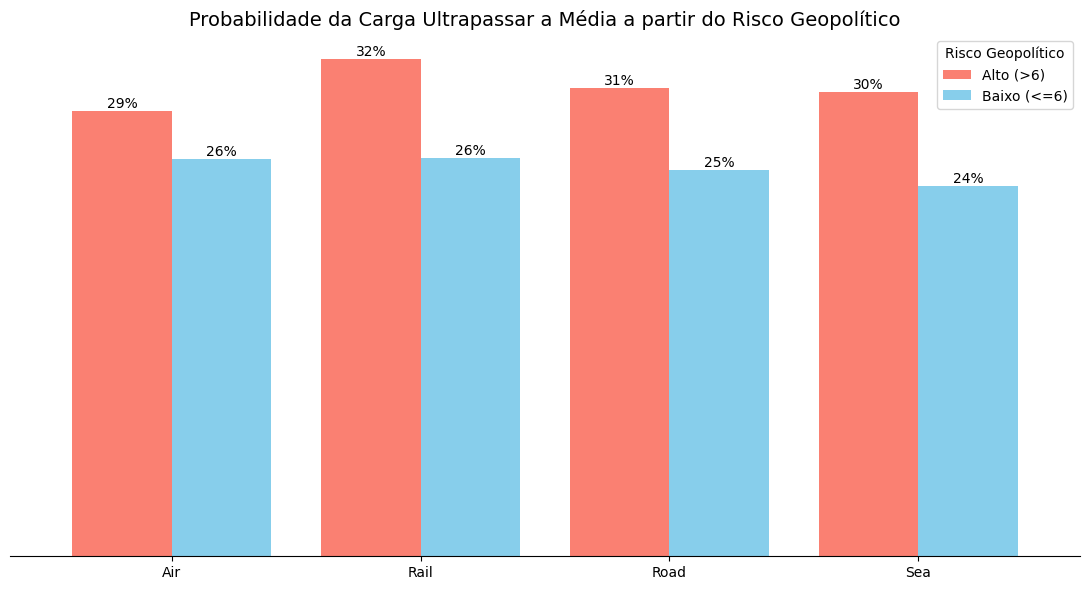

In [57]:
# 1. Calculando a média de Lead Time para CADA modal
medias_por_modal = df.groupby('Transport_Mode')['Lead_Time_Days'].mean()

# 2. Criando uma função para marcar o atraso relativo
def check_atraso_relativo(row):
    media_do_modal = medias_por_modal[row['Transport_Mode']]
    return 1 if row['Lead_Time_Days'] > media_do_modal else 0

df['Atraso_Relativo'] = df.apply(check_atraso_relativo, axis=1)

# 3. Preparando o gráfico comparativo
df['Risk_Level'] = df['Geopolitical_Risk_Score'].apply(lambda x: 'Baixo (<=6)' if x <= 6 else 'Alto (>6)')
grafico_dados = df.groupby(['Transport_Mode', 'Risk_Level'])['Atraso_Relativo'].mean().unstack() * 100

# 4. Plotando as Barras Agrupadas
ax = grafico_dados.plot(kind='bar', figsize=(11, 6), color=['salmon', 'skyblue'], width=0.8)
plt.title('Probabilidade da Carga Ultrapassar a Média a partir do Risco Geopolítico', fontsize=14)
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Risco Geopolítico')

plt.yticks([])
plt.ylabel('')

ax = plt.gca()

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Adicionar rótulos em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge')

plt.tight_layout()
plt.show()

**Insights relevantes:**

* O modal **Air** é, evidentemente, o mais confiável em tempos de crise. O aumento na probabilidade de atraso é a menor entre os quatro (**11,5%**, saltando de 26% para 29%). Embora seja o modal mais seguro para manter a operação, sua capacidade é limitada pela impossibilidade técnica de transportar equipamentos de grande porte ou peso excessivo.

* Os modais **Road (24%) e Rail (23%)** apresentam as maiores taxas de vulnerabilidade operacional em tempos de clima geopolítico fica mais instável. Logo, cargas transportadas nestes modais tem rota com risco geopolitico > 6 devem possuir um estoque de segurança *(safety stock)* para suprir qualquer paralisão e evitar perdas na produção.

* O modal martimo, **Sea (25%)**, é o mais vulnerável entre os quatro, principalmente, em tempos de crise geopolitica. Como vemos atualmente no Oriente Médio onde o acesso restrito a pontos estratégicos, como o Estreito de Ormuz (Irã/Pérsia), transforma o risco geopolítico em paralisia operacional, retendo cargas por tempo indeterminado e elevando drasticamente o custo e a incerteza deste modal.


###**2.4. Qual o impacto real das condições climáticas (`Weather_Severity_Rank`) no atraso médio de cada modal?**




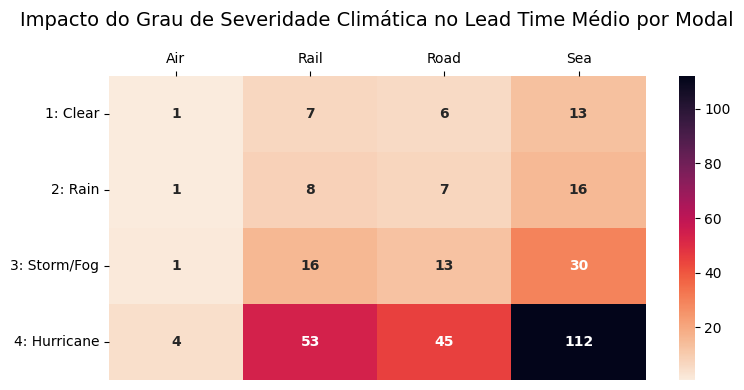

In [46]:
# Mapeamento para substituir números por nomes de forma clara
clima_nomes = {1: '1: Clear', 2: '2: Rain', 3: '3: Storm/Fog', 4: '4: Hurricane'}

# 1. Calculando a média de Lead Time e remodelando para o formato de tabela
# index = linhas (vertical), columns = colunas (horizontal)
df_clima_pivot = df.pivot_table(index='Weather_Severity_Rank',
                                columns='Transport_Mode',
                                values='Lead_Time_Days',
                                aggfunc='mean')

# Substituindo os códigos numéricos pelos nomes claros no índice (vertical)
df_clima_pivot.index = df_clima_pivot.index.map(clima_nomes)

# Garantindo que a ordem das linhas seja 1 (topo) a 4 (base) para lógica de tabela
df_clima_pivot = df_clima_pivot.reindex(['1: Clear', '2: Rain', '3: Storm/Fog', '4: Hurricane'])

plt.figure(figsize=(8, 4))


ax = sns.heatmap(df_clima_pivot,
                 annot=True, # annot=True: exibe os valores nas células
                 fmt=".0f",
                 cmap='rocket_r',
                 annot_kws={"size": 10, "weight": "bold"})

# títulos e Eixos (Ajustados para estilo de tabela)
plt.title('Impacto do Grau de Severidade Climática no Lead Time Médio por Modal\n', fontsize=14, pad=20)

# Colocando os rótulos do eixo X no topo (estilo cabeçalho de tabela)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Insights relevantes:**

* **Modal Air (Aéreo)**: Dentre os quatro modais, o aéreo é o mais resiliente sob a perspectiva climática. Observa-se que apenas em casos de severidade grau 4 (Hurricane) o modal sofre uma alteração significativa, aumentando o tempo médio de entrega (Lead Time) em **300%** (de **1 para 4 dias**).

* **Modal Rail (Ferroviário):** O impacto torna-se crítico a partir do grau 3 de severidade. Em cenários de nevoeiro (**Fog**) e furacão (**Hurricane**), o Lead Time aumenta drasticamente em **128%**(de 7 para 16) e **657%** (de 7 para 53), respectivamente, em relação às condições de céu limpo (Clear).

* **Modal Road (Rodoviário):** Este modal apresenta comportamento similar ao ferroviário. A partir do grau 3, o Lead Time médio aumenta **116%** (de 6 para 13) ao enfrentar situações de nevoeiro e **650%** (de 6 para 45) em condições extremas de furacão.

* **Modal Sea (Marítimo):** É o modal mais vulnerável a variações climáticas e janelas operacionais. Em situações de nevoeiro, o tempo médio de entrega cresce **131%** (de 13 para 30), enquanto em cenários de furacão, o impacto é severo, atingindo um aumento expressivo de **760%** (de 13 para 112) em relação a dias com condições climáticas favoráveis.


**Análise de Contingência Terrestre (Rail vs. Road):** A comparação entre os modais terrestres revela que o transporte rodoviário (**Road**) apresenta maior resiliência em cenários de crise, mantendo uma vantagem de **8 dias** (45 vs. 53 dias), isto é em média **18% mais ágil** em condições extremas de furacão (Hurricane) em relação ao ferroviário (**Rail**).

Essa diferença ocorre porque a malha ferroviária possui uma rigidez estrutural que impede desvios, enquanto o modal rodoviário permite rotas alternativas em caso de bloqueios físicos.

Portanto, o modal **Road** consolida-se como a principal alternativa de escape e redundância para cargas pesadas embora o **Rail** (ferroviário) seja eficiente em condições normais porém, a flexibilidade do caminhão deve ser levado em consideração para mitigar paralisias operacionais e garantir a continuidade do suprimento sob severidade climática.

###**2.5 Quais são as Top 7 rotas que combinam o maior Lead Time com o maior Risco Geopolítico?**

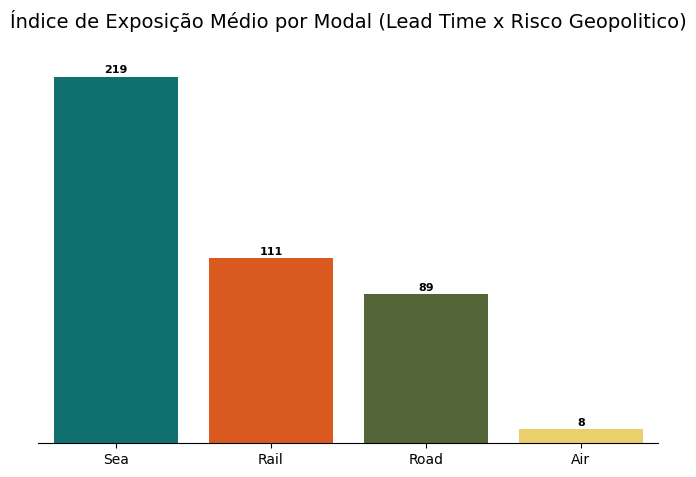

In [56]:
# Calculando a média do Índice de Exposição por Modal
df['Exposure_Index'] = df['Lead_Time_Days'] * df['Geopolitical_Risk_Score'] # a multiplicacao é utilizada porque o risco tem um efeito cumulativo sobre o tempo.

modal_exposure = df.groupby('Transport_Mode')['Exposure_Index'].mean().sort_values(ascending=False).reset_index()

# Visualização
plt.figure(figsize=(8, 5))
sns.barplot(data=modal_exposure, x='Transport_Mode', y='Exposure_Index', hue='Transport_Mode', palette=cores_modal, legend=False)

plt.title('Índice de Exposição Médio por Modal (Lead Time x Risco Geopolitico)\n', fontsize=14)
plt.xlabel('')

# Adicionando rótulos
for i, v in enumerate(modal_exposure['Exposure_Index']):
    plt.text(i, v + 2, f'{v:.0f}', ha='center', fontsize=8,  fontweight='bold')


plt.yticks([])
plt.ylabel('')

ax = plt.gca()

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.show()

**Insights relevantes:**

* O **modal aéreo (Air)**, com um índice residual de **8.5**, confirma sua posição não apenas como um modal rápido, mas como uma ferramenta de seguro operacional.

* O **modal marítimo (Sea)** apresenta um Índice de Exposição de **219.0**, o que é quase **26 vezes** maior que o **modal aéreo (Air)**. Isso demonstra que o frete marítimo carrega um custo oculto de exposição a riscos de atraso e incertezas geopolíticas extremamente elevado.

* Os modais **Rail e Road** operam em uma faixa de exposição intermediária (**89 e 110, respectivamente**). A diferença de **24%** sugere que, embora o ferroviário suporte mais carga, ele expõe a companhia a um risco de atraso ligeiramente superior ao rodoviário.

O índice de Exposição poderá ser utilizado para o cálculo de ***Safety Stock*** (estoque de segurança). Estipular um valor limite de exposição para cada modal (por ex. acima de 100 pontos) e exigem níveis de estoque mais agressivos para evitar a ruptura da linha de produção em caso de eventos geopolíticos.

###**2.6. Qual o impacto das interrupções (Disruption_Occurred) no Lead Time médio por modal?**

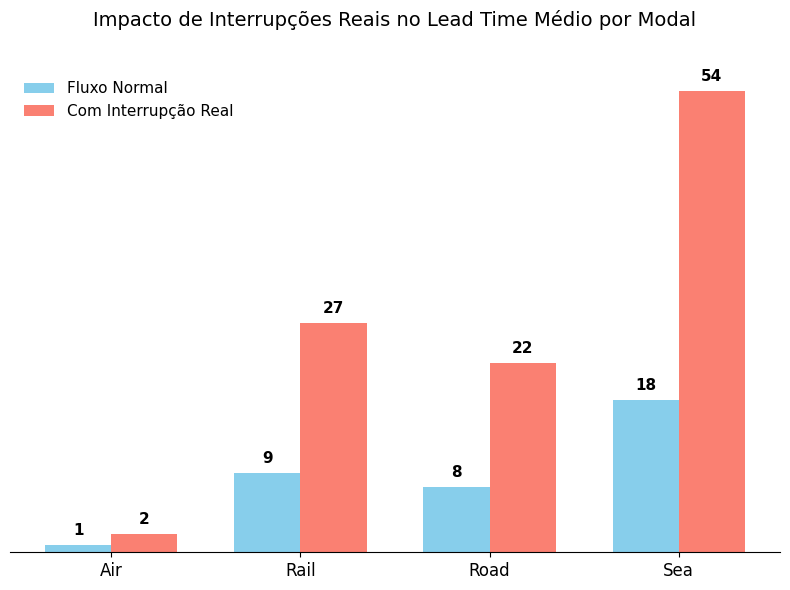

In [61]:
# Código para ver o impacto REAL das interrupções
disruption_impact = df.groupby(['Transport_Mode', 'Disruption_Occurred'])['Lead_Time_Days'].mean().unstack()


fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35
x = np.arange(len(disruption_impact.index))

# Criando as barras
bar1 = ax.bar(x - width/2, disruption_impact[0], width, label='Fluxo Normal', color='skyblue')
bar2 = ax.bar(x + width/2, disruption_impact[1], width, label='Com Interrupção Real', color='salmon')

# 3. Adicionando os Rótulos (Data Labels) no topo das barras
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 pontos de deslocamento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

add_labels(bar1)
add_labels(bar2)

# 4. Ajustes de Estética (Storytelling)
ax.set_title('Impacto de Interrupções Reais no Lead Time Médio por Modal',
             fontsize=14, loc='center', pad=30)

# Removendo Escala e Labels do Eixo Y conforme solicitado
ax.set_yticks([])
ax.set_ylabel('')

# Ajustando o Eixo X
ax.set_xticks(x)
ax.set_xticklabels(disruption_impact.index, fontsize=12)

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

**Insights relevantes:**

Enquanto o risco geopolítico é uma probabilidade, o atributo `Disruption_Occurred` representa o evento já concretizado (bloqueios, greves ou falhas mecânicas). Esta análise revela o quão sensível cada modal se torna quando o fluxo planejado é interrompido:

> **Modal Air (Aéreo):**

* Apesar de **dobrar o tempo de entrega**, o impacto prático é de apenas **1 dia adicional**.

* Mesmo em cenários de colapso, o modal entrega o componente em até 48h. Isso o consolida como a única opção viável para peças de reposição crítica (spares) que mantêm a continuidade da operação.

> **Modais Terrestres (Rail & Road):**

* **Rail (Ferroviário)**: Apresenta a maior sensibilidade relativa junto com o marítimo (200%). Isso reflete a **rigidez da malha**: em caso de interrupção em um trecho, a ausência de rotas de fuga acaba por **triplicar** o tempo de espera (**9 para 27 dias**).

* **Road (Rodoviário)**: Embora sofra um aumento expressivo de **175%,** demonstra maior flexibilidade que o ferroviário (**22 vs 27 dias** no cenário de crise). Essa vantagem deve-se à capacidade de redirecionamento dinâmico que a malha rodoviária permite frente a bloqueios físicos.

> **Modal Sea (Marítimo):**

* Sofre um aumento drástico de **200%**, saltando de **18 para 54 dias**, sendo assim o modal mais sensível para a continuidade operacional.

* Um **atraso de 36 dias** (mais de um mês) em suprimentos de grande portepode desestruturar cronogramas inteiros e gerar multas contratuais pesadas. No modal marítimo, a interrupção deixa de ser um mero atraso e torna-se um gargalo crítico para a operação.

